In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd 
from pathlib import Path
import seamless_3dep as s3dep
import rioxarray as rxr
import py3dep
import pickle
from shapely.geometry import Polygon

In [2]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [3]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

### Access 3DEP elevation data for plotting site fig

In [4]:
sierras_bbox = (-117.862654, 34.818611, -121.948903, 40.446988)

In [60]:
sierras.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [62]:
exploded_gdf = sierras.explode()

In [65]:
exploded_gdf_5070 = exploded_gdf.to_crs(epsg=5070)

In [66]:
exploded_gdf_5070['Area2'] = exploded_gdf_5070.geometry.area / 1e6  # in sq km

In [71]:
exploded_gdf['Area2'] = exploded_gdf_5070['Area2']

<Axes: >

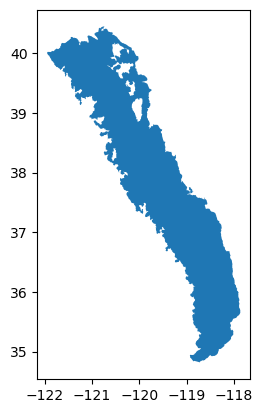

In [76]:
exploded_gdf[exploded_gdf['Area2'] == exploded_gdf['Area2'].max()].plot()

<Axes: >

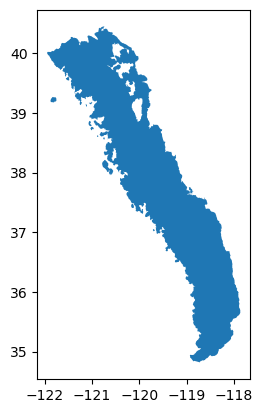

In [96]:
sierras.plot()

In [91]:
main_poly = exploded_gdf[(exploded_gdf['Area2'] == exploded_gdf['Area2'].max())]

<Axes: >

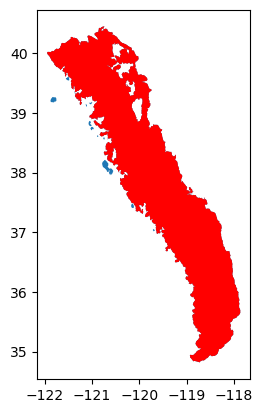

In [93]:
fig, ax = plt.subplots()
sierras.plot(ax=ax)
main_poly.plot(ax=ax, color='red')

In [94]:
poly = main_poly.loc[0, 'geometry']

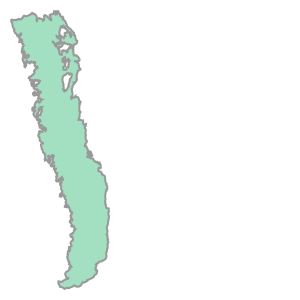

In [82]:
poly

In [95]:
dem_60 = py3dep.get_map("DEM", poly, resolution=60, geo_crs=4326, crs=4326)

In [97]:
dem_10 = py3dep.get_map("DEM", poly, resolution=10, geo_crs=4326, crs=4326)

TimeoutError: 

In [ ]:
sierras_10 = dem_10.rio.clip(sierras.geometry, sierras.crs, drop=True)

In [13]:
dem_200 = py3dep.get_map("DEM", sierras.geometry[0], resolution=200, geo_crs=4326, crs=4326)

GEOSException: Shell empty after removing invalid points

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

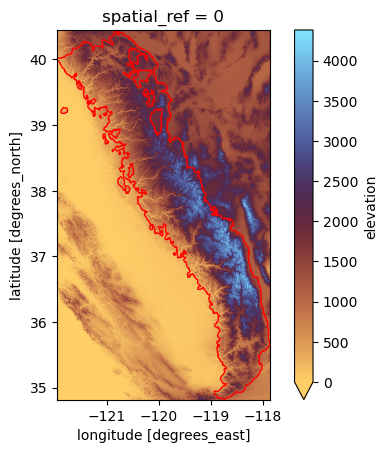

In [22]:
fig, ax = plt.subplots()

dem_200.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

In [25]:
sierras_200 = dem_200.rio.clip(sierras.geometry, sierras.crs, drop=True)

In [61]:
sierras_200.to_netcdf('../../data/3dep/dem_200m_sierras.nc')

Text(0.5, 1.0, '')

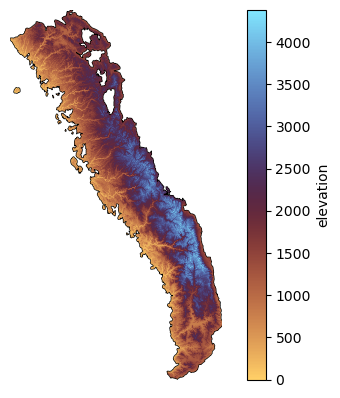

In [30]:
fig, ax = plt.subplots()

sierras_200.plot(ax=ax, cmap='managua', vmin=0, label='Elevation (m)')
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
ax.set_axis_off()
ax.set_title('')

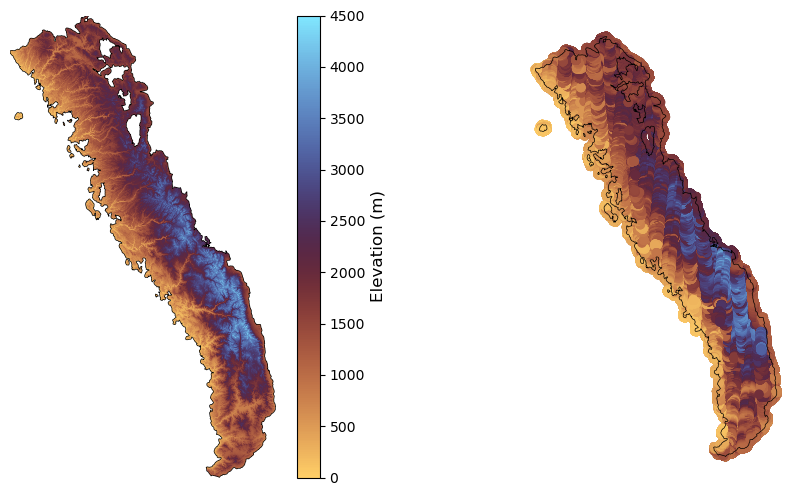

In [42]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierras.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

atl06sr_gdf.plot(column='h_mean', ax=ax[1], cmap='managua', vmin=0, vmax=4500)
sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
ax[1].set_axis_off()
ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

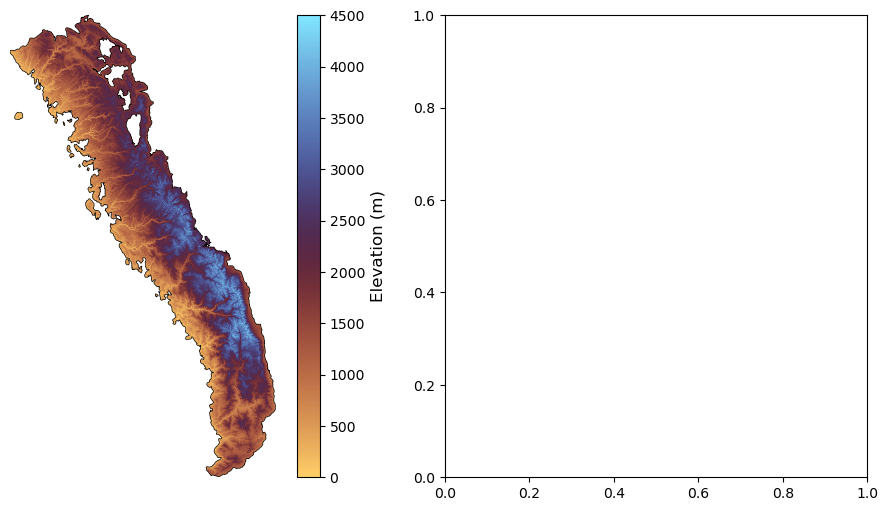

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

cax = sierras_200.plot(ax=ax[0], cmap='managua', vmin=0, vmax=4500, add_colorbar=False)
sierras.plot(ax=ax[0], facecolor="none", edgecolor="k", linewidth=0.5)
ax[0].set_axis_off()
ax[0].set_title('')

# atl06sr_gdf.plot(column='h_mean', ax=ax[1], cmap='managua', vmin=0, vmax=4500)
# sierras.plot(ax=ax[1], facecolor="none", edgecolor="k", linewidth=0.5)
# ax[1].set_axis_off()
# ax[1].set_title('')

cbar = fig.colorbar(cax)
cbar.set_label('Elevation (m)', size=12)

### Get elevation and slope for subset track:

In [5]:
import pickle

In [6]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [102]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [7]:
atl06sr_gdf_snowy = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20)]
atl06sr_gdf_snowy['n'] = atl06sr_gdf_snowy.groupby('acqdate')['acqdate'].transform('count')
atl06sr_gdf_snowy['acqdate_dt'] = pd.to_datetime(atl06sr_gdf_snowy['acqdate'])

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [8]:
highlight_dates = ['2019-03-16','2020-04-11','2021-04-01']

In [106]:
highlight_index = 2

min_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy[(atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[highlight_index]) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [107]:
subset_bbox = (min_x, min_y, max_x, max_y)

In [108]:
subset_dem_10 = py3dep.get_map("DEM", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

### Plot subset with slope and snow cover:

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

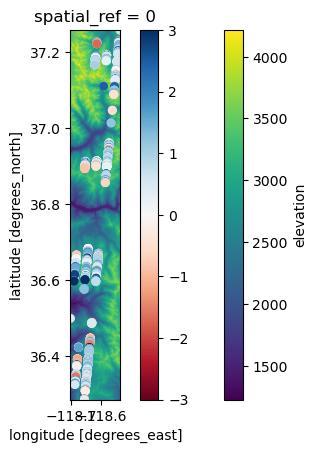

In [111]:
fig, ax =plt.subplots()
subset_dem_10.plot(ax=ax)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==highlight_dates[2]].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1


In [115]:
slope_crs = py3dep.get_map("Slope Degrees", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

### Do the same for April 7 instead of April 1, since it's a better track to show different key points

In [10]:
alt_highlight = pd.to_datetime('2021-04-07')

In [11]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

In [12]:
subset_bbox = (min_x, min_y, max_x, max_y)

In [13]:
slope_crs_alt = py3dep.get_map("Slope Degrees", subset_bbox, resolution=10, geo_crs=4326, crs=4326)

In [14]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [15]:
atl06sr_gdf_20slope = atl06sr_gdf[atl06sr_gdf['slope']<20]

In [16]:
import matplotlib.colors as mcolors

### Read in snow cover data:

In [ ]:
import xarray as xr

In [24]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [25]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [26]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [28]:
import matplotlib

(-118.84, -118.922)

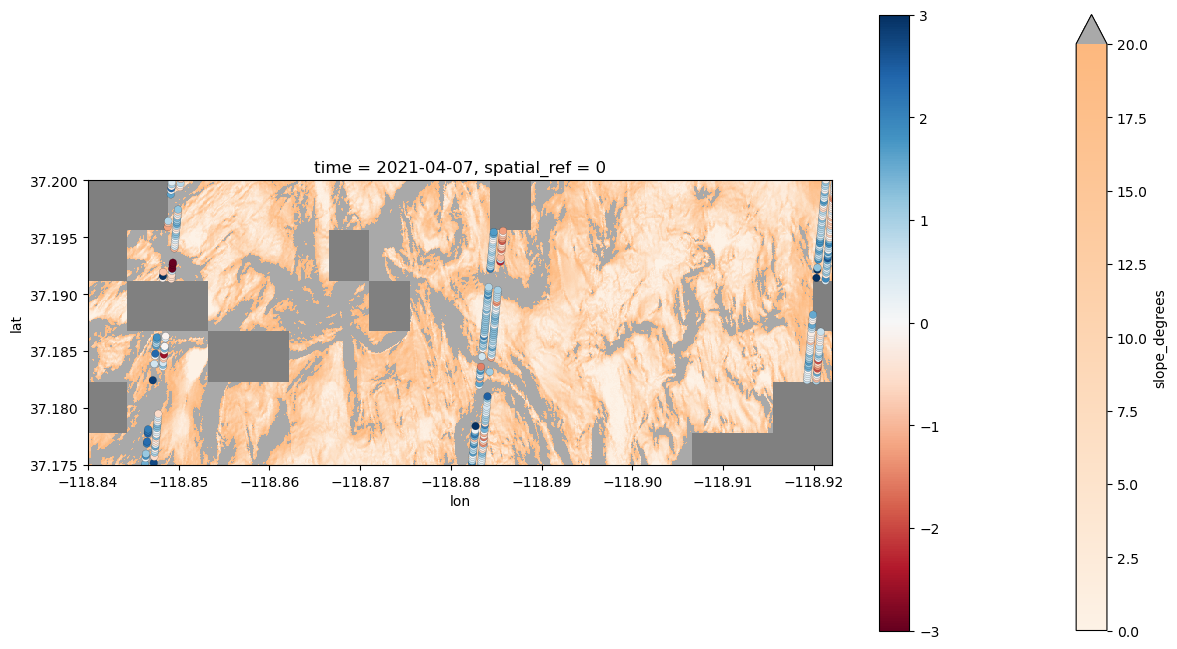

In [45]:


# 4. Plot the data using the custom norm and modified colormap
# Set the 'extend' keyword to include the 'over' color in the colorbar
# plt.imshow(data, cmap=cmap, norm=norm, extent=[0, 20, 0, 20])
# cbar = plt.colorbar(extend='max')

colors = ['#FDF2E6', '#fdb87e'] 



threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'darkgrey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.922)

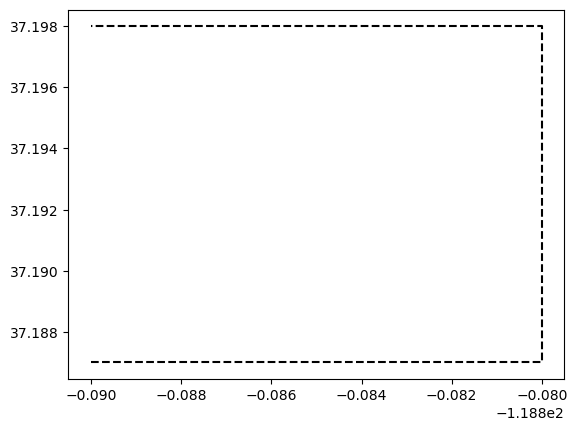

In [79]:
plt.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

Text(0.5, 1.0, '')

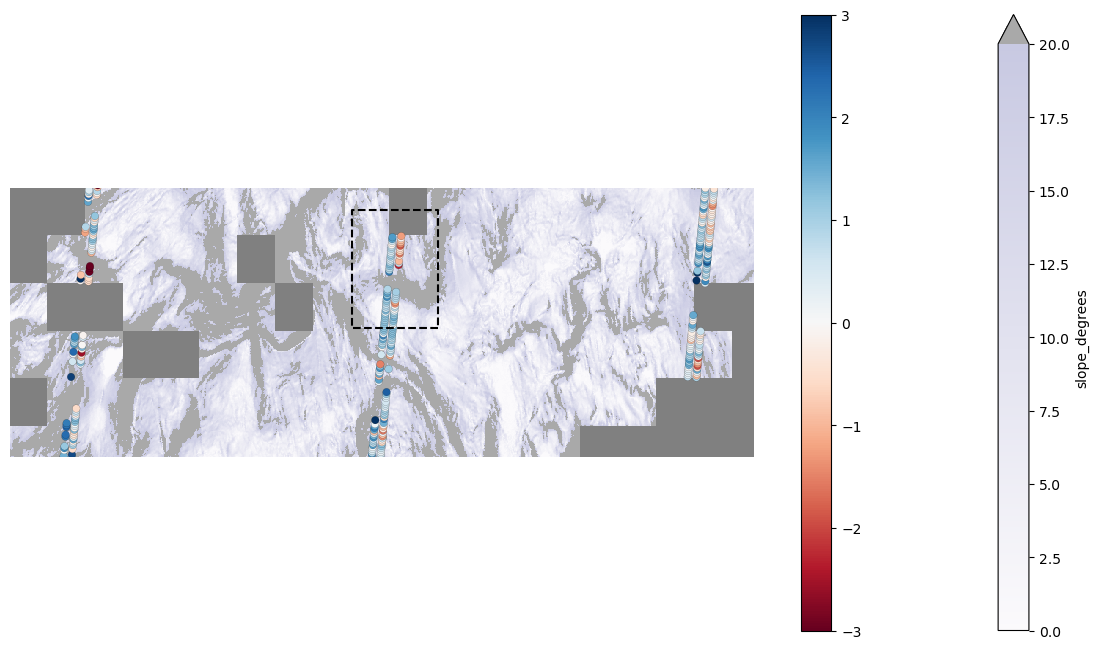

In [96]:
min_x = -118.89
min_y = 37.187
max_x = -118.88
max_y = 37.198

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']


threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'darkgrey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.927)
ax.set_axis_off()
ax.set_title('')

In [ ]:
min_x = -118.89
min_y = 37.187
max_x = -118.88
max_y = 37.198

region = [  {"lon": min_x, "lat": min_y},
            {"lon": max_x, "lat": min_y},
            {"lon": max_x, "lat": max_y},
            {"lon": min_x, "lat": max_y},
            {"lon": min_x, "lat": min_y}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']


threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'grey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.plot(region_lon, region_lat, linewidth=1.5, color='k', linestyle='--')
ax.set_ylim(37.175,37.2)
ax.set_xlim(-118.84,-118.927)
ax.set_axis_off()
ax.set_title('')

Text(0.5, 1.0, '')

Error in callback <function _draw_all_if_interactive at 0x13ece0220> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Text(0.5, 1.0, '')

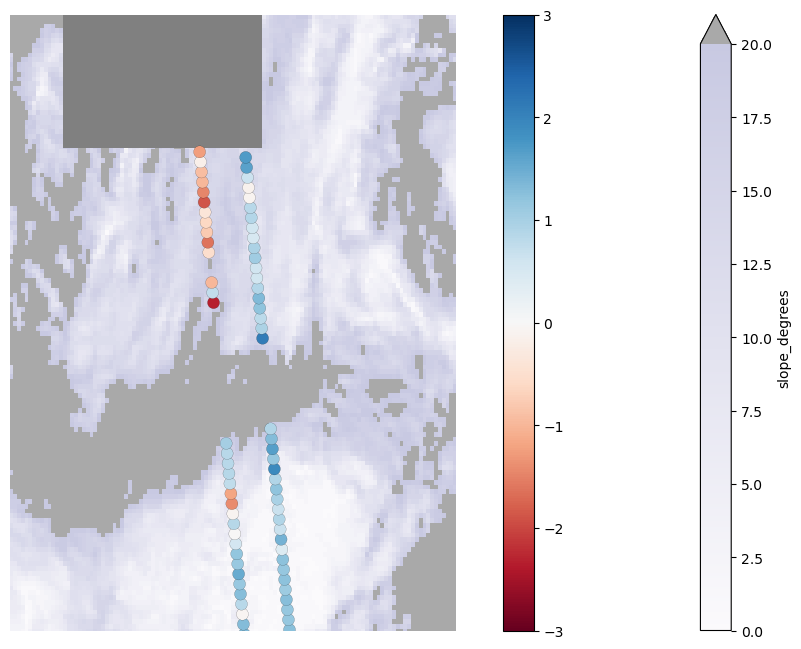

In [72]:


# 4. Plot the data using the custom norm and modified colormap
# Set the 'extend' keyword to include the 'over' color in the colorbar
# plt.imshow(data, cmap=cmap, norm=norm, extent=[0, 20, 0, 20])
# cbar = plt.colorbar(extend='max')

colors = ['#FDF2E6', '#fdb87e'] 
colors2 = ['#FBFAFC','#C8C9E2']


threshold_value = 0.9

cmap = mcolors.ListedColormap(['grey','blue', 'black'])
cmap.set_under('grey')
cmap.set_over('blue')

bounds = [threshold_value,1]
norm = mcolors.BoundaryNorm(bounds, cmap.N, extend='both') 

threshold_value1 = 20
# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list("my_custom_cmap", colors2)
#cmap1 = matplotlib.colormaps['Oranges'] # You can choose any built-in colormap
over_color1 = 'darkgrey' # The solid color for values above the threshold
custom_cmap.set_over(over_color1)
norm1 = mcolors.Normalize(vmin=0, vmax=threshold_value1)
# norm1 = mcolors.TwoSlopeNorm(vmin=0, vcenter=35, vmax=threshold_value1)


fig, ax =plt.subplots(figsize=(15,8))
slope_crs_alt.plot(ax=ax, cmap=custom_cmap, norm=norm1)
swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #, cbar_kwargs={'ticks': bounds}
# swe_sca_ds.SCA_Post.sel(time=alt_highlight).where(swe_sca_ds.SCA_Post.sel(time=alt_highlight)<0.9).plot(ax=ax, color='red', alpha=0.7)
#atl06sr_gdf[atl06sr_gdf['acqdate_dt']==alt_highlight].plot(ax=ax, markersize=30, color='black', alpha=0.3, vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
#atl06sr_gdf_20slope[atl06sr_gdf_20slope['acqdate_dt']==alt_highlight].plot(ax=ax,markersize=30, alpha=0.3,color='red', vmin=-3, vmax=3) # , edgecolor='k', linewidth=0.1
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=75, cmap='RdBu', edgecolor='k', linewidth=0.1,vmin=-3, vmax=3, legend=True) # 
ax.set_ylim(37.187,37.198)
ax.set_xlim(-118.89,-118.88)
ax.set_axis_off()
ax.set_title('')

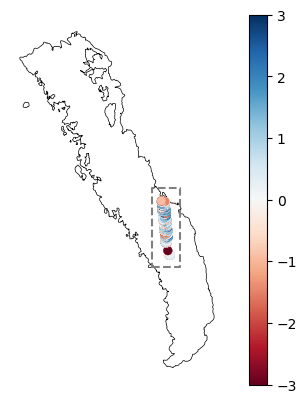

In [93]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.2

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax =plt.subplots()
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.set_axis_off()


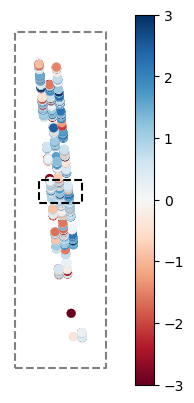

In [94]:
min_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.min()
min_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.min()
max_x = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.x.max()
max_y = atl06sr_gdf_snowy.loc[(atl06sr_gdf_snowy['acqdate_dt']==alt_highlight) & (atl06sr_gdf_snowy['n']>100)].geometry.y.max()

buffer = 0.1

region = [  {"lon": min_x - buffer, "lat": min_y- buffer},
            {"lon": max_x + buffer, "lat": min_y- buffer},
            {"lon": max_x+ buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": max_y+ buffer},
            {"lon": min_x- buffer, "lat": min_y- buffer}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]


buffer2 = 0.05

min_x2 = -118.84 + buffer2
min_y2 = 37.175 + buffer2
max_x2 = -118.922 - buffer2
max_y2 = 37.2 - buffer2

region2 = [  {"lon": min_x2, "lat": min_y2},
            {"lon": max_x2, "lat": min_y2},
            {"lon": max_x2, "lat": max_y2},
            {"lon": min_x2, "lat": max_y2},
            {"lon": min_x2, "lat": min_y2}  ]

region_lon2 = [e["lon"] for e in region2]
region_lat2 = [e["lat"] for e in region2]


# ax.set_ylim(37.175,37.2)
# ax.set_xlim(-118.84,-118.922)


fig, ax =plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5)
atl06sr_gdf_snowy[atl06sr_gdf_snowy['acqdate_dt']==alt_highlight].plot(ax=ax, column='icesat2_3dep_dif',markersize=30, cmap='RdBu', legend=True, vmin=-3, vmax=3)
ax.plot(region_lon, region_lat, linewidth=1.5, color='grey', linestyle='--')
ax.plot(region_lon2, region_lat2, linewidth=1.5, color='k', linestyle='--')

ax.set_axis_off()


In [60]:
region_lon

[-118.97350744825745,
 -118.78919450191879,
 -118.78919450191879,
 -118.97350744825745,
 -118.97350744825745]

### Reference map:

In [37]:
usa = gpd.read_file('../../data/misc/cb_2018_us_state_500k/cb_2018_us_state_500k.shp')

In [46]:
usa.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

Text(0.5, 1.0, '')

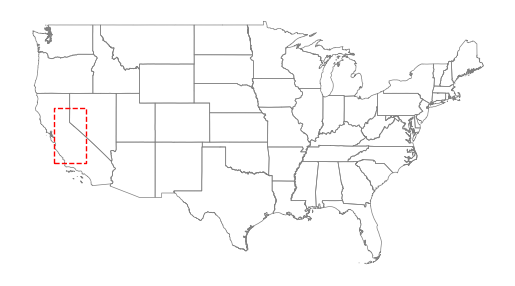

In [48]:
non_conus = ['Alaska', 'Hawaii', 'Puerto Rico', 
              'American Samoa', 'Commonwealth of the Northern Mariana Islands', 
              'Guam', 'United States Virgin Islands']

region = [  {"lon": -121.948903, "lat": 34.818611},
            {"lon": -117.862654, "lat": 34.818611},
            {"lon": -117.862654, "lat": 40.446988},
            {"lon": -121.948903, "lat": 40.446988},
            {"lon": -121.948903, "lat": 34.818611}  ]

region_lon = [e["lon"] for e in region]
region_lat = [e["lat"] for e in region]

fig, ax = plt.subplots()
#sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
usa[~usa['NAME'].isin(non_conus)].to_crs('epsg:4326').plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')

ax.set_axis_off()
ax.set_title('')

(32.0, 43.0)

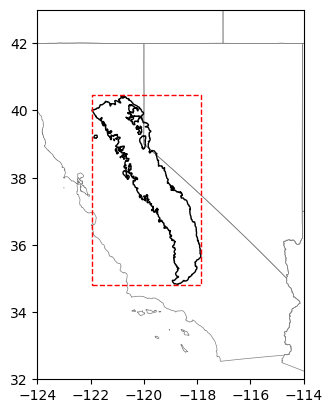

In [60]:
fig, ax = plt.subplots()
usa.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)
sierras.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=1)
ax.plot(region_lon, region_lat, linewidth=1, color='r', linestyle='--')
ax.set_xlim(-124, -114)
ax.set_ylim(32, 43)

### Higher resolution, probably unnecessary:

In [16]:
dem = py3dep.get_map("DEM", sierras_bbox, resolution=60, geo_crs=4326, crs=4326)

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

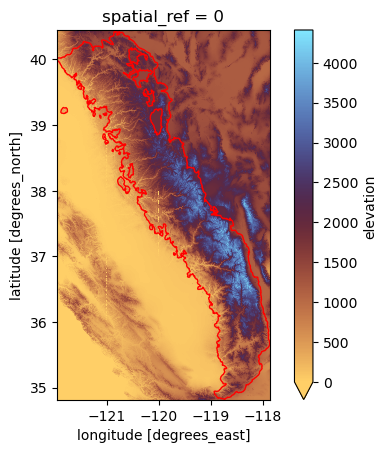

In [23]:
fig, ax = plt.subplots()

dem.plot(ax=ax, cmap='managua', vmin=0)
sierras.plot(ax=ax, facecolor="none", edgecolor="red")

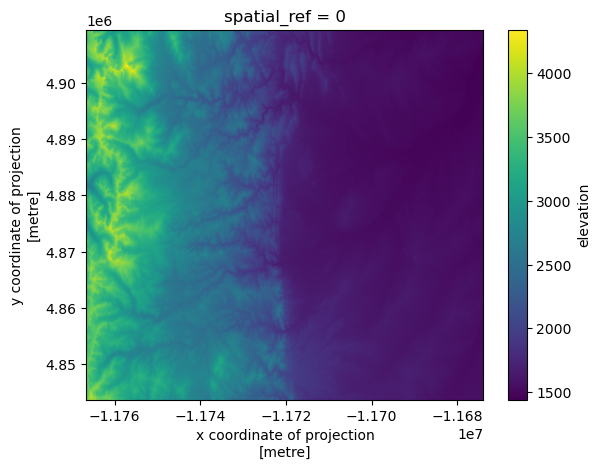

In [6]:
dem.plot()

In [ ]:
slope = py3dep.get_map("Slope Degrees", geom, resolution=30)
slope = py3dep.deg2mpm(slope)